# H-QNN v2 — Leave-One-Rat-Out (LORO) Cross-Validation
## ResNet-50 (layer4 fine-tunável) → FC → PQC → Classificador Linear

**Avaliação inter-sujeito com metodologia LORO:**
- Rato 1 = teste fixo (nunca visto durante o treino nem na validação)
- Folds: cada um dos 10 ratos restantes (2,3,4,5,6,7,8,9,10,11) é usado como validação; os outros 9 treinam
- Ao final: resultados individuais por fold + média ± desvio padrão + ensemble dos 10 modelos no teste

**Hiperparâmetros:**
- N_QUBITS=8, N_LAYERS=5, BasicEntanglerLayers (RX)
- layer4 da ResNet-50 descongelada (fine-tuning)
- Adam com 3 grupos de lr | CosineAnnealingLR | label_smoothing=0.1
- Early stopping patience=20 | Max 100 épocas por fold
- TTA_STEPS=5 na avaliação final

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
from pathlib import Path
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              balanced_accuracy_score, confusion_matrix)

plt.rcParams['figure.dpi'] = 120

In [3]:
# ── Configuração Global ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

N_QUBITS      = 8
N_LAYERS      = 5
NUM_EPOCHS    = 100
BATCH_SIZE    = 32
PATIENCE      = 15
TTA_STEPS     = 5
TEST_RAT_ID   = 1

METADATA_PATH = Path('../datasets/rats/metadata-1.csv')
IMAGES_DIR    = Path('../datasets/rats/images')
CKPT_DIR      = Path('checkpoints_v2')
CKPT_DIR.mkdir(exist_ok=True)

LABEL_PT = {'warm-up': 'Baixo', 'moderate': 'Moderado', 'heavy': 'Intenso', 'severe': 'Severo'}

print(f'Dispositivo : {DEVICE}')
print(f'N_QUBITS    : {N_QUBITS}  |  N_LAYERS: {N_LAYERS}')
print(f'Épocas max  : {NUM_EPOCHS}  |  Patience: {PATIENCE}')

Dispositivo : cuda:0
N_QUBITS    : 8  |  N_LAYERS: 5
Épocas max  : 100  |  Patience: 15


In [4]:
# ── Dataset customizado (lê do CSV + pasta de imagens) ────────────────────────
class RatDataset(Dataset):
    """
    Carrega imagens de ratos a partir de um DataFrame filtrado.
    O DataFrame deve conter as colunas 'filename' e 'class'.
    As imagens são buscadas em IMAGES_DIR/<filename>.
    """
    def __init__(self, df: pd.DataFrame, images_dir: Path, transform=None):
        self.df          = df.reset_index(drop=True)
        self.images_dir  = images_dir
        self.transform   = transform
        self.classes     = sorted(df['class'].unique().tolist())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.images_dir / row['filename']).convert('RGB')
        label = self.class_to_idx[row['class']]
        if self.transform:
            img = self.transform(img)
        return img, label

In [5]:
# ── Transforms ────────────────────────────────────────────────────────────────
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
tta_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
])

# ── Carrega metadata e separa teste fixo ──────────────────────────────────────
df_full    = pd.read_csv(METADATA_PATH)
test_df    = df_full[df_full['mice_id'] == TEST_RAT_ID].reset_index(drop=True)
trainval_df = df_full[df_full['mice_id'] != TEST_RAT_ID].reset_index(drop=True)

ALL_CLASSES   = sorted(df_full['class'].unique().tolist())
CLASS_TO_IDX  = {c: i for i, c in enumerate(ALL_CLASSES)}
N_CLASSES     = len(ALL_CLASSES)
RAT_IDS       = sorted(trainval_df['mice_id'].unique().tolist())

print(f'Classes ({N_CLASSES}): {ALL_CLASSES}')
print(f'Ratos train/val: {RAT_IDS}')
print(f'Imagens treino+val : {len(trainval_df)}')
print(f'Imagens teste fixo : {len(test_df)}  (rato {TEST_RAT_ID})')

Classes (4): ['heavy', 'moderate', 'severe', 'warm-up']
Ratos train/val: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Imagens treino+val : 27305
Imagens teste fixo : 4513  (rato 1)


In [6]:
# ── Circuito Quântico (PQC) ───────────────────────────────────────────────────
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='X')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS), rotation=qml.RX)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(N_QUBITS)]

In [7]:
# ── Modelo H-QNN v2 ───────────────────────────────────────────────────────────
class HybridQuantumModel(nn.Module):
    """
    ResNet-50 (layer4 fine-tunável) → FC(2048, N_QUBITS)
    → sigmoid*pi → PQC (BasicEntanglerLayers RX) → Dropout → Linear
    """
    def __init__(self, n_classes: int, n_qubits: int, n_layers: int):
        super().__init__()
        self.resnet = models.resnet50(weights='DEFAULT')
        for param in self.resnet.parameters():
            param.requires_grad = False
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True
        in_features    = self.resnet.fc.in_features  # 2048
        self.resnet.fc = nn.Linear(in_features, n_qubits)
        weight_shapes  = {'weights': (n_layers, n_qubits)}
        self.qlayer    = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.dropout   = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(n_qubits, n_classes)

    def _init_quantum_weights(self):
        with torch.no_grad():
            self.qlayer.weights.data = torch.randn_like(self.qlayer.weights) * 0.01

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.resnet(x)
        x = torch.sigmoid(x) * np.pi
        x = self.qlayer(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [8]:
# ── Funções Auxiliares ────────────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc  = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true,  y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true,  y_pred, average='macro', zero_division=0)
    return acc, f1, prec, rec


def predict_tta(model, inputs, n_steps):
    """Média das probabilidades sobre n_steps versões augmentadas do batch."""
    probs = torch.softmax(model(inputs), dim=1)
    for _ in range(n_steps - 1):
        aug_inputs = torch.stack([tta_transform(img) for img in inputs])
        probs = probs + torch.softmax(model(aug_inputs), dim=1)
    return probs / n_steps


def avaliar_no_teste(model, test_loader, criterion):
    """Avalia modelo no conjunto de teste com TTA. Retorna métricas e loss."""
    model.eval()
    rl = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            probs = predict_tta(model, inputs, TTA_STEPS)
            preds = torch.argmax(probs, dim=1)
            loss  = criterion(model(inputs), labels)
            rl   += loss.item() * inputs.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    test_loss = rl / len(test_loader.dataset)
    acc, f1, prec, rec = calcular_metricas(y_true, y_pred)
    return test_loss, acc, f1, prec, rec

In [9]:
# ── Função de Treino de um Fold ───────────────────────────────────────────────
def treinar_fold(fold_idx, train_df, val_df, val_rat_id):
    """
    Treina um fold completo e salva o melhor checkpoint.
    Retorna (modelo, criterion, val_metrics, ckpt_path, history).
    """
    print(f'\n{"=" * 72}')
    print(f'FOLD {fold_idx:>2}/10  —  val = rato {val_rat_id}  '
          f'|  treino={len(train_df)}  val={len(val_df)} imagens')
    print('=' * 72)

    # Datasets e loaders
    train_ds = RatDataset(train_df, IMAGES_DIR, transform=transform_treino)
    val_ds   = RatDataset(val_df,   IMAGES_DIR, transform=transform_eval)

    # Garante que a ordem das classes é consistente com ALL_CLASSES
    train_ds.classes      = ALL_CLASSES
    train_ds.class_to_idx = CLASS_TO_IDX
    val_ds.classes        = ALL_CLASSES
    val_ds.class_to_idx   = CLASS_TO_IDX

    train_loader_f = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=2, pin_memory=True)
    val_loader_f   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=True)

    # Pesos de classe calculados no split de treino deste fold
    train_labels  = [CLASS_TO_IDX[c] for c in train_df['class']]
    class_counts  = np.bincount(train_labels, minlength=N_CLASSES)
    class_counts  = np.maximum(class_counts, 1)
    class_weights = len(train_labels) / (N_CLASSES * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    # Modelo, critério e otimizador
    model = HybridQuantumModel(N_CLASSES, N_QUBITS, N_LAYERS)
    model._init_quantum_weights()
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    optimizer = optim.Adam([
        {'params': model.resnet.layer4.parameters(),
         'lr': 1e-5, 'weight_decay': 1e-4},
        {'params': list(model.resnet.fc.parameters()) + list(model.classifier.parameters()),
         'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': model.qlayer.parameters(),
         'lr': 1e-4, 'weight_decay': 1e-5},
    ])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
    )

    ckpt_path        = CKPT_DIR / f'fold_{fold_idx:02d}_rat{val_rat_id}.pt'
    best_val_loss    = float('inf')
    patience_counter = 0
    best_val_metrics = None
    history          = {'train_loss': [], 'val_loss': [], 'epoch_times': []}

    ROW_H = '  {:<10}  {:>8}  {:>8}  {:>8}  {:>9}  {:>8}'
    ROW_V = '  {:<10}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>9.4f}  {:>8.4f}'

    for epoch in range(1, NUM_EPOCHS + 1):
        t_ep_start = time.time()

        # ── Treino ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        y_true_t, y_pred_t = [], []
        for inputs, labels in train_loader_f:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            y_true_t.extend(labels.cpu().numpy())
            y_pred_t.extend(preds.cpu().numpy())
        train_loss = running_loss / len(train_ds)
        tr_acc, tr_f1, tr_prec, tr_rec = calcular_metricas(y_true_t, y_pred_t)

        # ── Validação ─────────────────────────────────────────────────────
        model.eval()
        running_loss_v = 0.0
        y_true_v, y_pred_v = [], []
        with torch.no_grad():
            for inputs, labels in val_loader_f:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                running_loss_v += loss.item() * inputs.size(0)
                y_true_v.extend(labels.cpu().numpy())
                y_pred_v.extend(preds.cpu().numpy())
        val_loss = running_loss_v / len(val_ds)
        vl_acc, vl_f1, vl_prec, vl_rec = calcular_metricas(y_true_v, y_pred_v)

        # ── Histórico ─────────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_times'].append(time.time() - t_ep_start)

        scheduler.step()

        # ── Checkpoint + Early Stopping ───────────────────────────────────
        marker = ''
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_val_metrics = (vl_acc, vl_f1, vl_prec, vl_rec)
            torch.save(model.state_dict(), ckpt_path)
            marker = '  ✓'
        else:
            patience_counter += 1

        current_lr = scheduler.get_last_lr()[0]
        print(f'\n  Época {epoch:>3}/{NUM_EPOCHS}  lr={current_lr:.1e}  '
              f'patience={patience_counter}/{PATIENCE}{marker}')
        print(ROW_H.format('', 'Perda', 'Ac.Bal.', 'F1', 'Precisao', 'Recall'))
        print(ROW_V.format('Treino',    train_loss, tr_acc, tr_f1, tr_prec, tr_rec))
        print(ROW_V.format('Validacao', val_loss,   vl_acc, vl_f1, vl_prec, vl_rec))

        if patience_counter >= PATIENCE:
            print(f'\n  Early stopping na época {epoch}.')
            break

    print(f'\n  Melhor val loss: {best_val_loss:.4f}  →  {ckpt_path.name}')

    # Carrega o melhor checkpoint antes de retornar
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return model, criterion, best_val_metrics, ckpt_path, history

In [10]:
# ── LORO Cross-Validation ─────────────────────────────────────────────────────
logo = LeaveOneGroupOut()
groups = trainval_df['mice_id'].values

# Dataset de teste fixo (rato 1) — sem augmentation
test_ds     = RatDataset(test_df, IMAGES_DIR, transform=transform_eval)
test_ds.classes      = ALL_CLASSES
test_ds.class_to_idx = CLASS_TO_IDX
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# Listas para acumular resultados
fold_results    = []   # dicts com métricas de validação e teste por fold
modelos_fold    = []   # modelos treinados (para ensemble)
criterions_fold = []   # criterion de cada fold (para ensemble loss)
fold_histories  = []   # histórico de perdas por fold (para curva de perda)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
t_loro_start = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(
        logo.split(trainval_df, groups=groups), start=1):

    train_df_fold = trainval_df.iloc[train_idx]
    val_df_fold   = trainval_df.iloc[val_idx]
    val_rat       = int(val_df_fold['mice_id'].iloc[0])

    model_fold, criterion_fold, best_val_m, ckpt, history_fold = treinar_fold(
        fold_idx, train_df_fold, val_df_fold, val_rat
    )

    # Avalia no teste fixo (rato 1)
    t_loss, t_acc, t_f1, t_prec, t_rec = avaliar_no_teste(
        model_fold, test_loader, criterion_fold
    )

    fold_results.append({
        'fold':      fold_idx,
        'val_rat':   val_rat,
        'val_acc':   best_val_m[0],
        'val_f1':    best_val_m[1],
        'val_prec':  best_val_m[2],
        'val_rec':   best_val_m[3],
        'test_loss': t_loss,
        'test_acc':  t_acc,
        'test_f1':   t_f1,
        'test_prec': t_prec,
        'test_rec':  t_rec,
        'ckpt':      str(ckpt),
    })
    modelos_fold.append(model_fold)
    criterions_fold.append(criterion_fold)
    fold_histories.append(history_fold)

    print(f'\n  [Fold {fold_idx}] Teste (rato 1): '
          f'Ac.Bal={t_acc:.4f}  F1={t_f1:.4f}  '
          f'Prec={t_prec:.4f}  Rec={t_rec:.4f}')

t_loro_total  = time.time() - t_loro_start
fold_ep_means = [np.mean(h['epoch_times']) for h in fold_histories]
mean_ep_time  = np.mean(fold_ep_means)
vram_peak_gb  = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0.0

print('\n\nLORO concluído — todos os 10 folds treinados.')
print(f'Tempo total (10 folds)       : {t_loro_total:.1f} s  ({t_loro_total/60:.1f} min)')
print(f'Tempo médio por época (média): {mean_ep_time:.1f} s')
print(f'Pico de VRAM                 : {vram_peak_gb:.2f} GB  (torch.cuda.max_memory_allocated)')


FOLD  1/10  —  val = rato 2  |  treino=24984  val=2321 imagens

  Época   1/100  lr=1.0e-05  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        1.2195    0.6214    0.5161     0.5715    0.6214
  Validacao     1.5554    0.3797    0.2807     0.3903    0.2848


/home/quantum/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  Época   2/100  lr=1.0e-05  patience=1/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.9904    0.8008    0.7018     0.6970    0.8008
  Validacao     1.5916    0.3890    0.2825     0.3930    0.2918


/home/quantum/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  Época   3/100  lr=1.0e-05  patience=2/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.9226    0.8330    0.7360     0.7287    0.8330
  Validacao     1.6183    0.3906    0.2840     0.3718    0.2929


...


  Época  15/100  lr=9.5e-06  patience=14/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.7414    0.9523    0.8882     0.8614    0.9523
  Validacao     1.9523    0.5006    0.3617     0.4972    0.3755


/home/quantum/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  Época  16/100  lr=9.4e-06  patience=15/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.7391    0.9544    0.8924     0.8655    0.9544
  Validacao     2.0169    0.5355    0.3534     0.4786    0.4016

  Early stopping na época 16.

  Melhor val loss: 1.6375  →  fold_07_rat8.pt


/home/quantum/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  [Fold 7] Teste (rato 1): Ac.Bal=0.4691  F1=0.2948  Prec=0.5190  Rec=0.4691

FOLD  8/10  —  val = rato 9  |  treino=24012  val=3293 imagens

  Época   1/100  lr=1.0e-05  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        1.2412    0.6567    0.5319     0.5680    0.6567
  Validacao     1.3078    0.5544    0.5333     0.5480    0.5544

  Época   2/100  lr=1.0e-05  patience=1/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        1.0026    0.8253    0.7150     0.7072    0.8253
  Validacao     1.3335    0.5518    0.5385     0.5608    0.5518

  Época   3/100  lr=1.0e-05  patience=0/15  ✓
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.9296    0.8617    0.7501     0.7412    0.8617
  Validacao     1.2491    0.6015    0.5935     0.5972    0.6015

  Época   4/100  lr=1.0e-05  patience=1/15
                 Perda   Ac.Bal.        F1   Precisao    Recall
  Treino        0.9033    0.8740    

In [11]:
# ── Tabela de Resultados por Fold ─────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)

# Formata para exibição
display_cols = ['fold', 'val_rat',
                'val_acc', 'val_f1', 'val_prec', 'val_rec',
                'test_acc', 'test_f1', 'test_prec', 'test_rec']
print_df = results_df[display_cols].copy()

# Linha de média ± desvio padrão
metric_cols = ['val_acc', 'val_f1', 'val_prec', 'val_rec',
               'test_acc', 'test_f1', 'test_prec', 'test_rec']
means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()

print('\n' + '=' * 90)
print('Resultados LORO — por Fold')
print('=' * 90)

HDR = ('{:>6}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  '
       '{:>8}  {:>8}  {:>8}  {:>8}')
ROW = ('{:>6}  {:>8}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}  '
       '{:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}')

print(HDR.format('Fold', 'Val-Rato',
                 'vAc.Bal', 'vF1', 'vPrec', 'vRec',
                 'tAc.Bal', 'tF1', 'tPrec', 'tRec'))
print('-' * 90)
for r in fold_results:
    print(ROW.format(
        r['fold'], r['val_rat'],
        r['val_acc'],  r['val_f1'],  r['val_prec'],  r['val_rec'],
        r['test_acc'], r['test_f1'], r['test_prec'], r['test_rec'],
    ))
print('-' * 90)

MU  = ('{:>6}  {:>8}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}  '
       '{:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}')
SD  = ('{:>6}  {:>8}  {:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}  '
       '{:>8.4f}  {:>8.4f}  {:>8.4f}  {:>8.4f}')
print(MU.format('Media', '',
                means['val_acc'],  means['val_f1'],  means['val_prec'],  means['val_rec'],
                means['test_acc'], means['test_f1'], means['test_prec'], means['test_rec']))
print(SD.format('Desvio', '',
                stds['val_acc'],  stds['val_f1'],  stds['val_prec'],  stds['val_rec'],
                stds['test_acc'], stds['test_f1'], stds['test_prec'], stds['test_rec']))
print('=' * 90)


Resultados LORO — por Fold
  Fold  Val-Rato   vAc.Bal       vF1     vPrec      vRec   tAc.Bal       tF1     tPrec      tRec
------------------------------------------------------------------------------------------
     1         2    0.3797    0.2807    0.3903    0.2848    0.4422    0.2845    0.5098    0.4422
     2         3    0.3499    0.2466    0.2405    0.2624    0.5807    0.5426    0.6139    0.5807
     3         4    0.4742    0.2606    0.2957    0.2371    0.5432    0.4359    0.4804    0.5432
     4         5    0.7367    0.5615    0.5771    0.5525    0.2782    0.1708    0.3709    0.2782
     5         6    0.8453    0.8557    0.8883    0.8453    0.3929    0.3243    0.4571    0.3929
     6         7    0.8189    0.6124    0.6149    0.6141    0.4243    0.3970    0.5924    0.4243
     7         8    0.5261    0.3559    0.4711    0.3945    0.4691    0.2948    0.5190    0.4691
     8         9    0.6474    0.6455    0.6445    0.6474    0.3266    0.2218    0.4376    0.3266
     9  

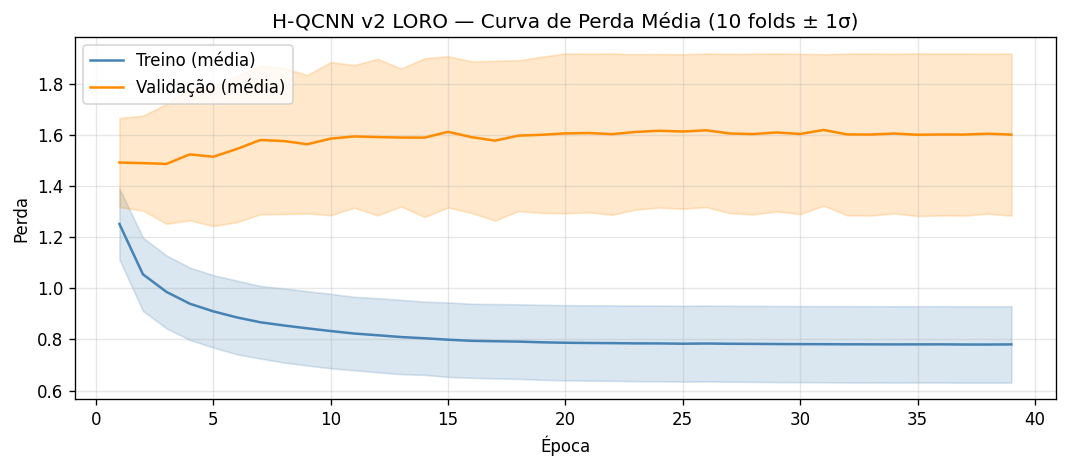

In [17]:
# ── Curva de Perda por Fold — Média ± Desvio Padrão ──────────────────────────
def pad_to(vals, length):
    """Estende lista repetindo o último valor até o comprimento desejado."""
    return vals + [vals[-1]] * (length - len(vals))

max_len      = max(len(h['train_loss']) for h in fold_histories)
train_matrix = np.array([pad_to(h['train_loss'], max_len) for h in fold_histories])
val_matrix   = np.array([pad_to(h['val_loss'],   max_len) for h in fold_histories])

epochs_ax = np.arange(1, max_len + 1)
tr_mean, tr_std = train_matrix.mean(axis=0), train_matrix.std(axis=0)
vl_mean, vl_std = val_matrix.mean(axis=0),   val_matrix.std(axis=0)

plt.figure(figsize=(9, 4))
plt.plot(epochs_ax, tr_mean, label='Treino (média)',    color='steelblue')
plt.fill_between(epochs_ax, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='steelblue')
plt.plot(epochs_ax, vl_mean, label='Validação (média)', color='darkorange')
plt.fill_between(epochs_ax, vl_mean - vl_std, vl_mean + vl_std, alpha=0.2, color='darkorange')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('H-QCNN v2 LORO — Curva de Perda Média (10 folds ± 1σ)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('v2_loss_curve.pdf', bbox_inches='tight')
plt.show()

In [13]:
# ── Ensemble Final (média dos 10 modelos + TTA) ───────────────────────────────
print('\n' + '=' * 72)
print('Avaliação Final — Ensemble dos 10 modelos (rato 1, com TTA)')
print('=' * 72)

for m in modelos_fold:
    m.eval()

# Usa o criterion do primeiro fold só para calcular a perda do ensemble
criterion_ens = criterions_fold[0]

rl_ens = 0.0
y_true_ens, y_pred_ens = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Acumula softmax de cada modelo (com TTA)
        ensemble_probs = torch.zeros(inputs.size(0), N_CLASSES, device=DEVICE)
        for m in modelos_fold:
            ensemble_probs += predict_tta(m, inputs, TTA_STEPS)
        ensemble_probs /= len(modelos_fold)

        preds = torch.argmax(ensemble_probs, dim=1)
        loss  = criterion_ens(modelos_fold[0](inputs), labels)  # loss de referência
        rl_ens += loss.item() * inputs.size(0)

        y_true_ens.extend(labels.cpu().numpy())
        y_pred_ens.extend(preds.cpu().numpy())

ens_loss = rl_ens / len(test_ds)
ens_acc, ens_f1, ens_prec, ens_rec = calcular_metricas(y_true_ens, y_pred_ens)

print(f'  TTA steps       : {TTA_STEPS}')
print(f'  Modelos ensemble: {len(modelos_fold)}')
print(f'  Perda (ref)     : {ens_loss:.4f}')
print(f'  Ac. Balanceada  : {ens_acc:.4f}')
print(f'  F1-Score        : {ens_f1:.4f}  (macro)')
print(f'  Precisao        : {ens_prec:.4f}  (macro)')
print(f'  Recall          : {ens_rec:.4f}  (macro)')


Avaliação Final — Ensemble dos 10 modelos (rato 1, com TTA)
  TTA steps       : 5
  Modelos ensemble: 10
  Perda (ref)     : 1.4313
  Ac. Balanceada  : 0.5988
  F1-Score        : 0.4437  (macro)
  Precisao        : 0.5210  (macro)
  Recall          : 0.5988  (macro)


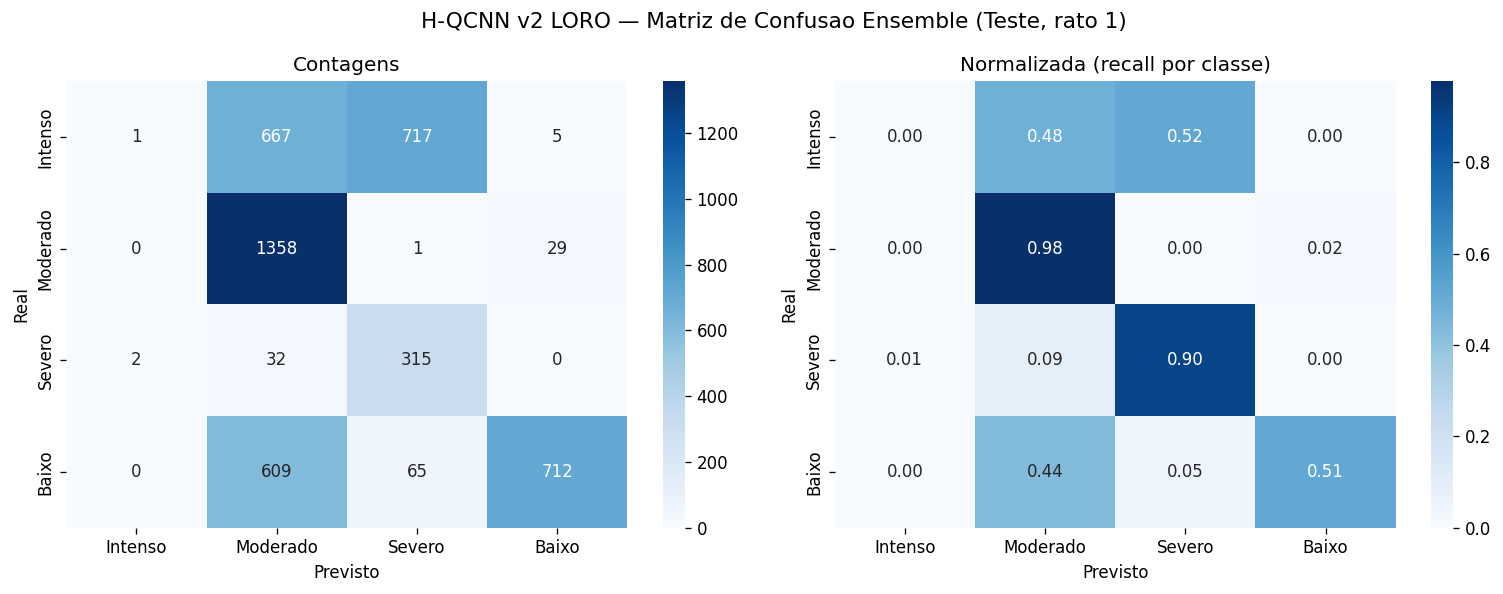

In [18]:
# ── Matriz de Confusão — Ensemble ─────────────────────────────────────────────
cm      = confusion_matrix(y_true_ens, y_pred_ens)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

all_classes_pt = [LABEL_PT.get(c, c) for c in ALL_CLASSES]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes_pt, yticklabels=all_classes_pt, ax=axes[0])
axes[0].set_title('Contagens', fontsize=12)
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=all_classes_pt, yticklabels=all_classes_pt, ax=axes[1])
axes[1].set_title('Normalizada (recall por classe)', fontsize=12)
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.suptitle('H-QCNN v2 LORO — Matriz de Confusao Ensemble (Teste, rato 1)', fontsize=13)
plt.tight_layout()
plt.savefig('v2_confusion_matrix.pdf', bbox_inches='tight')
plt.show()

Calculando SHAP values (pode levar alguns minutos)...
Usando fold 6 (val=rato 7) para SHAP
Amostras selecionadas: 4  (uma por classe)
shap_arr.shape: (4, 3, 224, 224, 4)  |  B=4
shap_importance.shape: (4, 224, 224)


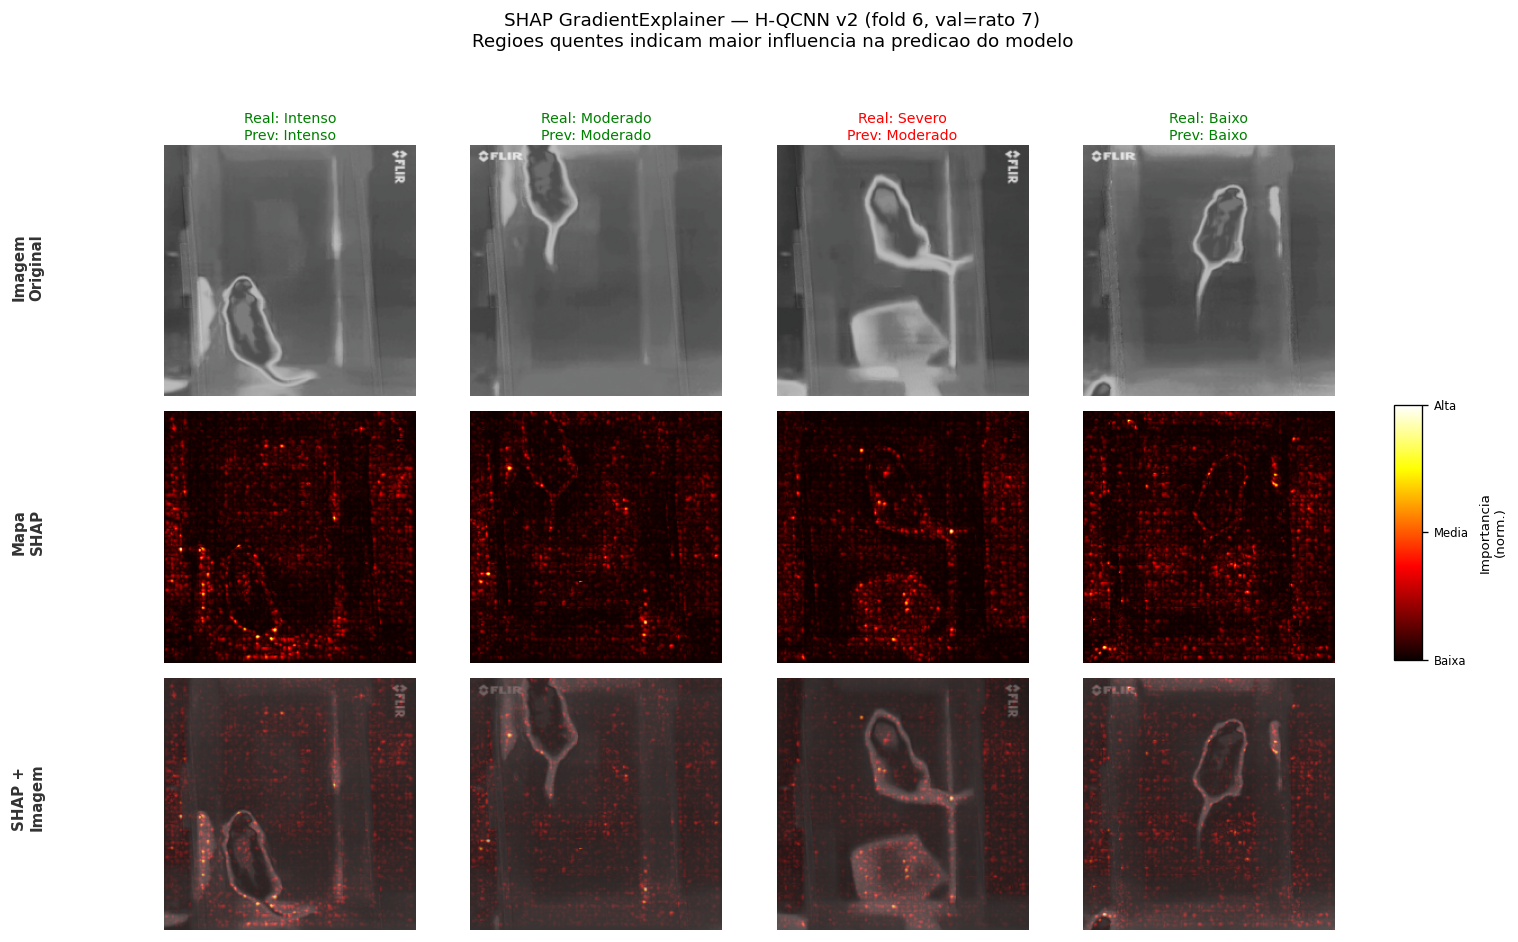

Salvo: v2_shap.pdf


In [19]:
# ── SHAP — GradientExplainer (melhor fold) ───────────────────────────────────
print('Calculando SHAP values (pode levar alguns minutos)...')

# Seleciona o fold com menor test loss
best_fold_idx = int(np.argmin([r['test_loss'] for r in fold_results]))
best_model    = modelos_fold[best_fold_idx]
best_rat      = fold_results[best_fold_idx]['val_rat']
print(f'Usando fold {best_fold_idx + 1} (val=rato {best_rat}) para SHAP')
best_model.eval()

# Background: 32 amostras do treino deste fold
all_splits_tmp    = list(LeaveOneGroupOut().split(trainval_df, groups=groups))
train_idx_fold, _ = all_splits_tmp[best_fold_idx]
train_df_fold_bg  = trainval_df.iloc[train_idx_fold].sample(
                        n=min(32, len(train_idx_fold)), random_state=SEED
                    ).reset_index(drop=True)
bg_ds             = RatDataset(train_df_fold_bg, IMAGES_DIR, transform=transform_eval)
bg_ds.classes     = ALL_CLASSES
bg_ds.class_to_idx = CLASS_TO_IDX
bg_loader         = DataLoader(bg_ds, batch_size=32, shuffle=False)
bg_images, _      = next(iter(bg_loader))
bg_images         = bg_images.to(DEVICE)

# ── Seleciona UMA imagem por classe do conjunto de teste ─────────────────────
rng_sel = np.random.default_rng(SEED + 1)
local_idx = [
    test_df.reset_index(drop=True).index[
        test_df.reset_index(drop=True)['class'] == cls
    ].tolist()
    for cls in ALL_CLASSES
]
selected_local_idx = [
    int(rng_sel.choice(idxs)) if idxs else 0
    for idxs in local_idx
]

exp_images = torch.stack([test_ds[i][0] for i in selected_local_idx]).to(DEVICE)
exp_labels = torch.tensor([test_ds[i][1] for i in selected_local_idx])
B_exp      = exp_images.size(0)
print(f'Amostras selecionadas: {B_exp}  (uma por classe)')

# SHAP values
explainer   = shap.GradientExplainer(best_model, bg_images)
shap_values = explainer.shap_values(exp_images)

# ── Normaliza para (B, H, W) — detecta formato automaticamente ───────────────
shap_arr = np.abs(np.array(shap_values))
print(f'shap_arr.shape: {shap_arr.shape}  |  B={B_exp}')

if shap_arr.ndim == 5 and shap_arr.shape[0] == B_exp:
    shap_importance = shap_arr.mean(axis=(1, 4))
elif shap_arr.ndim == 5 and shap_arr.shape[1] == B_exp:
    shap_importance = shap_arr.mean(axis=(0, 2))
elif shap_arr.ndim == 5 and shap_arr.shape[2] == B_exp:
    shap_importance = shap_arr.mean(axis=(0, 1))
elif shap_arr.ndim == 4 and shap_arr.shape[0] == B_exp:
    shap_importance = shap_arr.mean(axis=1)
else:
    raise ValueError(f'Formato SHAP nao mapeado: {shap_arr.shape}, B={B_exp}')

print(f'shap_importance.shape: {shap_importance.shape}')

# Desfaz normalização ImageNet
_mean  = np.array([0.485, 0.456, 0.406])
_std   = np.array([0.229, 0.224, 0.225])
exp_np = exp_images.cpu().numpy().transpose(0, 2, 3, 1)
exp_np = np.clip(exp_np * _std + _mean, 0, 1)

with torch.no_grad():
    preds_shap = best_model(exp_images).argmax(dim=1).cpu().numpy()

# ── Figura para dissertação: 3 linhas × N_CLASSES colunas ────────────────────
N_SHOW = N_CLASSES
fig, axes = plt.subplots(3, N_SHOW,
                          figsize=(3.2 * N_SHOW, 8.5),
                          gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
fig.subplots_adjust(left=0.09, right=0.88)

for r in range(3):
    for c in range(N_SHOW):
        axes[r, c].axis('off')

ROW_LABELS = ['Imagem\nOriginal', 'Mapa\nSHAP', 'SHAP +\nImagem']

for col in range(N_SHOW):
    true_orig = ALL_CLASSES[exp_labels[col].item()]
    pred_orig = ALL_CLASSES[preds_shap[col]]
    true_lbl  = LABEL_PT.get(true_orig, true_orig)
    pred_lbl  = LABEL_PT.get(pred_orig, pred_orig)
    cor       = 'green' if true_orig == pred_orig else 'red'
    sm        = shap_importance[col]
    sm        = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    axes[0, col].imshow(exp_np[col])
    axes[0, col].set_title(f'Real: {true_lbl}\nPrev: {pred_lbl}',
                            fontsize=8.5, color=cor, pad=3)

    im = axes[1, col].imshow(sm, cmap='hot', vmin=0, vmax=1)

    axes[2, col].imshow(exp_np[col])
    axes[2, col].imshow(sm, cmap='hot', alpha=0.55)

# Labels das linhas
row_centers = [0.76, 0.50, 0.24]
for yc, lbl in zip(row_centers, ROW_LABELS):
    fig.text(0.005, yc, lbl, fontsize=9, va='center',
             ha='left', rotation=90, fontweight='bold', color='#333333')

# Colorbar
cbar_ax = fig.add_axes([0.905, 0.375, 0.018, 0.25])
cb = plt.colorbar(im, cax=cbar_ax)
cb.set_label('Importancia\n(norm.)', fontsize=8, labelpad=6)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(['Baixa', 'Media', 'Alta'], fontsize=7)

plt.suptitle(f'SHAP GradientExplainer — H-QCNN v2 '
             f'(fold {best_fold_idx + 1}, val=rato {best_rat})\n'
             'Regioes quentes indicam maior influencia na predicao do modelo',
             fontsize=11, y=1.01)
plt.savefig('v2_shap.pdf', bbox_inches='tight')
plt.show()
print('Salvo: v2_shap.pdf')

In [16]:
# ── Comparação LORO vs Bernini ────────────────────────────────────────────────
print('\n' + '=' * 72)
print('Comparação H-QNN v2 (LORO Ensemble) vs Bernini (ResNet50 + RF)')
print('=' * 72)

BERNINI = {'Recall': 0.3879, 'Precisao': 0.4667, 'F1-Score': 0.3817}
HQNN_V2 = {'Recall': ens_rec, 'Precisao': ens_prec, 'F1-Score': ens_f1}

print(f"{'Metrica':<22} {'Bernini':>10} {'H-QNN v2':>10} {'Delta':>8}")
print('-' * 54)
for m in ('Recall', 'Precisao', 'F1-Score'):
    delta = HQNN_V2[m] - BERNINI[m]
    sinal = '+' if delta >= 0 else ''
    print(f'{m:<22} {BERNINI[m]:>10.4f} {HQNN_V2[m]:>10.4f} {sinal}{delta:>7.4f}')

print('\n  Nota: Bernini = melhor modelo 4 classes (rato 1 como teste, split estratificado 10%)')
print('  H-QNN v2     = ensemble LORO — 10 modelos, TTA=5, rato 1 nunca visto no treino')


Comparação H-QNN v2 (LORO Ensemble) vs Bernini (ResNet50 + RF)
Metrica                   Bernini   H-QNN v2    Delta
------------------------------------------------------
Recall                     0.3879     0.5988 + 0.2109
Precisao                   0.4667     0.5210 + 0.0543
F1-Score                   0.3817     0.4437 + 0.0620

  Nota: Bernini = melhor modelo 4 classes (rato 1 como teste, split estratificado 10%)
  H-QNN v2     = ensemble LORO — 10 modelos, TTA=5, rato 1 nunca visto no treino
